In [91]:
import pandas as pd
import numpy as np

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_error

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 1. Carga y Preprocesamiento de Datos

In [92]:
# Carga y preprocesamiento de datos
df = pd.read_csv("../inputs/dataset_v2_fs_top60_+2.csv")

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.sort_values("fecha")

# Renombrar columna target
df = df.rename(columns={"merval_apertura_+2": "merval"})

# Configurar índice temporal con frecuencia diaria
df.set_index("fecha", inplace=True)
df.index = df.index.to_period("D")

# Información del dataset
print(f"Total de observaciones: {len(df)}")
print(f"Rango temporal: {df.index.min()} a {df.index.max()}")

Total de observaciones: 643
Rango temporal: 2023-01-02 a 2025-08-27


In [93]:
# Verificar que no haya NAs en la variable objetivo
print(f"Filas con NA en 'merval': {df.loc[df['merval'].isna()].shape[0]}")
df = df.loc[df['merval'].notna()]

Filas con NA en 'merval': 0


## 2. Análisis Exploratorio

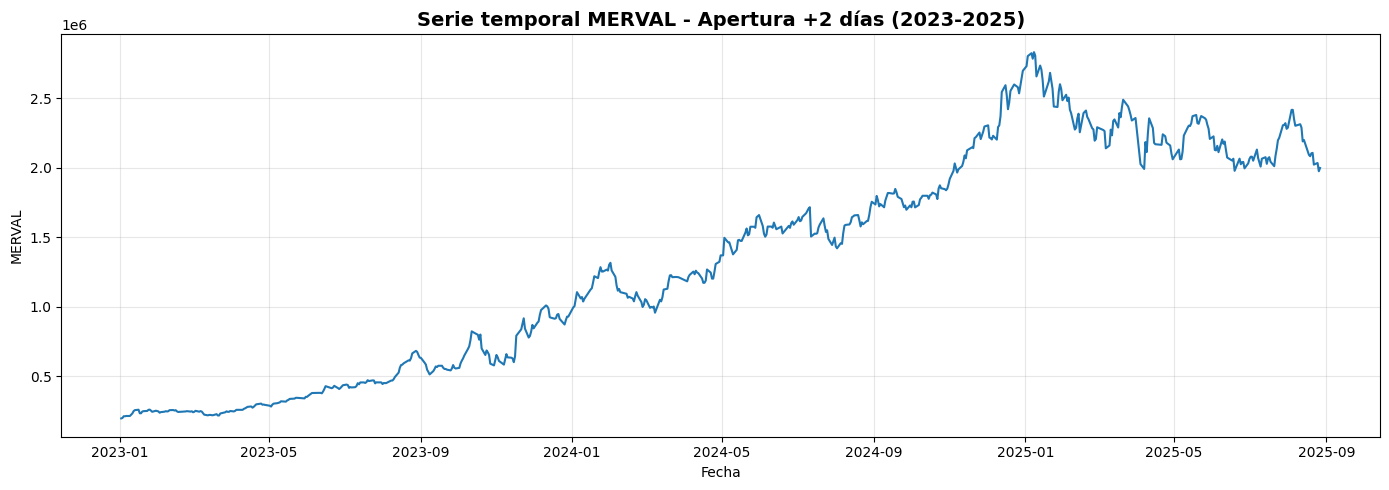

\nTest de estacionariedad (Augmented Dickey-Fuller)
ADF Statistic: -1.1115
p-value: 0.7105
Es estacionaria (p < 0.05): False
La serie NO es estacionaria, necesita diferenciación (d >= 1)


In [94]:
# Visualización de la serie temporal
plt.figure(figsize=(14, 5))
plt.plot(df.index.to_timestamp(), df['merval'])
plt.title('Serie temporal MERVAL - Apertura +2 días (2023-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('MERVAL')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Test de estacionariedad (Augmented Dickey-Fuller)
result = adfuller(df['merval'].dropna())
print('\\nTest de estacionariedad (Augmented Dickey-Fuller)')
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print(f'Es estacionaria (p < 0.05): {result[1] < 0.05}')
if result[1] > 0.05:
    print('La serie NO es estacionaria, necesita diferenciación (d >= 1)')
else:
    print('La serie es estacionaria')

In [95]:
# Train-test split (80/20)
series = df["merval"]
train_size = int(len(series) * 0.8)
train, test = series.iloc[:train_size], series.iloc[train_size:]

print(f'Train: {train.index.min()} a {train.index.max()} ({len(train)} observaciones)')
print(f'Test:  {test.index.min()} a {test.index.max()} ({len(test)} observaciones)')

Train: 2023-01-02 a 2025-02-11 (514 observaciones)
Test:  2025-02-12 a 2025-08-27 (129 observaciones)


## 3. Búsqueda del Mejor Orden ARIMA (Grid Search)

In [96]:
# Probar diferentes combinaciones de (p, d, q)
import itertools

p_values = range(0, 4)
d_values = range(0, 2)
q_values = range(0, 4)

best_aic = np.inf
best_order = None

results = []

for p, d, q in itertools.product(p_values, d_values, q_values):
    try:
        model_temp = ARIMA(train, order=(p, d, q))
        fitted_temp = model_temp.fit()
        aic = fitted_temp.aic
        results.append({'order': (p, d, q), 'AIC': aic})
        
        if aic < best_aic:
            best_aic = aic
            best_order = (p, d, q)
    except:
        continue

print(f"Mejor modelo por AIC: ARIMA{best_order}")
print(f"AIC: {best_aic:.2f}")

# Mostrar top 5 modelos
results_df = pd.DataFrame(results).sort_values('AIC')
print("\\nTop 5 modelos por AIC:")
print(results_df.head())

Mejor modelo por AIC: ARIMA(2, 1, 3)
AIC: 12225.38
\nTop 5 modelos por AIC:
        order           AIC
23  (2, 1, 3)  12225.384656
30  (3, 1, 2)  12225.919546
31  (3, 1, 3)  12227.770762
5   (0, 1, 1)  12231.055097
22  (2, 1, 2)  12231.091689


In [97]:
# Entrenar modelo ARIMA con el mejor orden encontrado
model = ARIMA(train, order=best_order)
res = model.fit()

# Mostrar resumen estadístico
print(res.summary())

# Predicción out-of-sample
forecast = res.forecast(steps=len(test))
forecast.index = test.index

# Calcular métricas de evaluación
rmse = root_mean_squared_error(test, forecast)
mae = mean_absolute_error(test, forecast)
mape = np.mean(np.abs((test - forecast) / test)) * 100

print(f"\\nMétricas del modelo ARIMA{best_order}:")
print(f"  RMSE: {rmse:12,.2f}")
print(f"  MAE:  {mae:12,.2f}")
print(f"  MAPE: {mape:11.2f}%")

                               SARIMAX Results                                
Dep. Variable:                 merval   No. Observations:                  514
Model:                 ARIMA(2, 1, 3)   Log Likelihood               -6106.692
Date:                Sat, 15 Nov 2025   AIC                          12225.385
Time:                        21:57:57   BIC                          12250.826
Sample:                    01-02-2023   HQIC                         12235.357
                         - 02-11-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8072      0.010     83.703      0.000       0.788       0.826
ar.L2         -0.9892      0.010    -97.517      0.000      -1.009      -0.969
ma.L1         -0.6729      0.042    -16.081      0.0

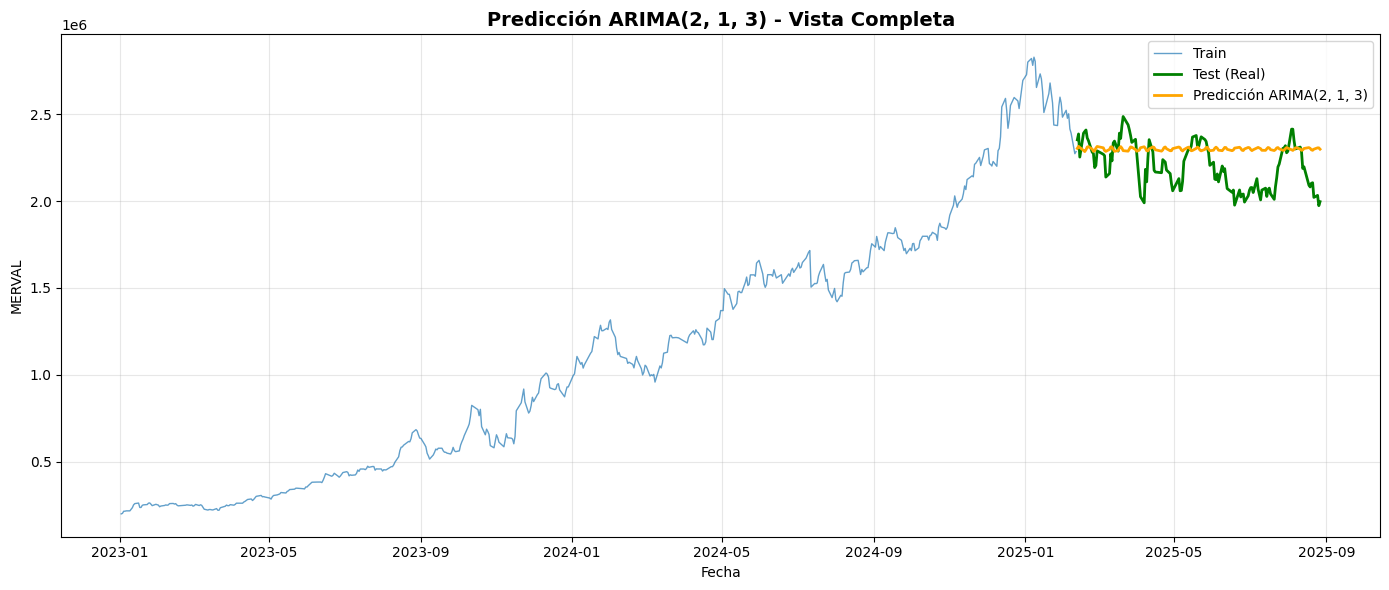

In [98]:
# Visualización completa: Train, Test y Predicción
plt.figure(figsize=(14, 6))
plt.plot(train.index.to_timestamp(), train, label="Train", alpha=0.7, linewidth=1)
plt.plot(test.index.to_timestamp(), test, label="Test (Real)", color='green', linewidth=2)
plt.plot(forecast.index.to_timestamp(), forecast, label=f"Predicción ARIMA{best_order}", color="orange", linewidth=2)
plt.title(f"Predicción ARIMA{best_order} - Vista Completa", fontsize=14, fontweight='bold')
plt.xlabel("Fecha")
plt.ylabel("MERVAL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

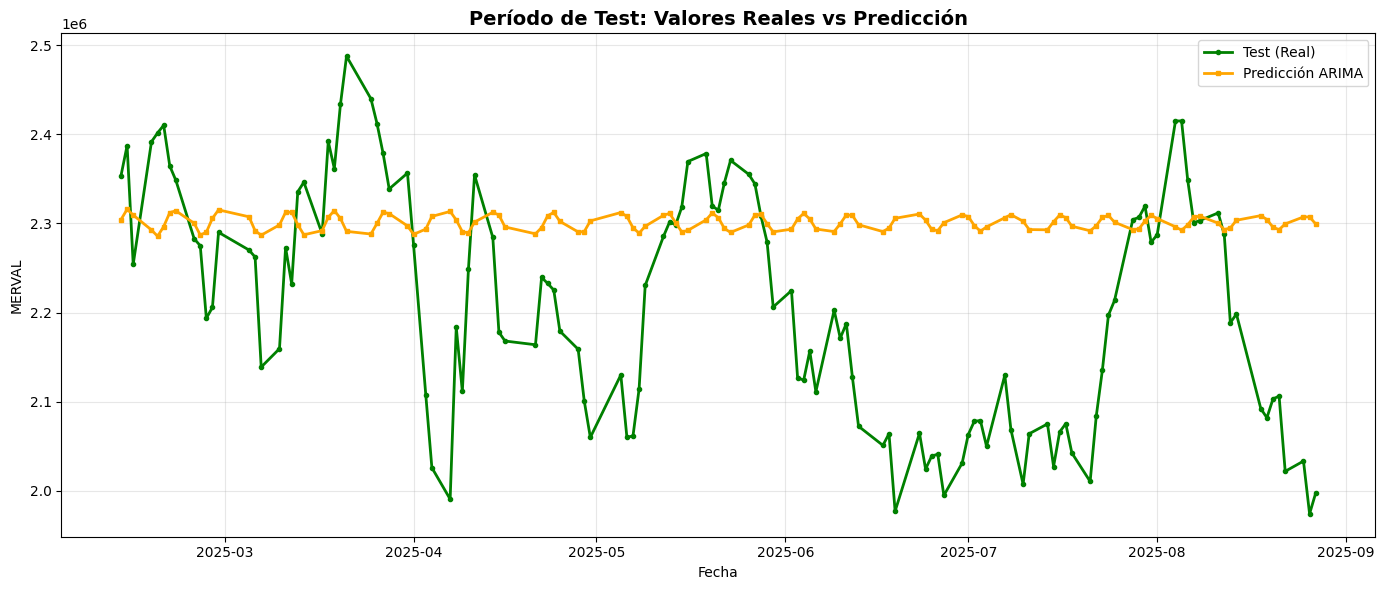

In [99]:
# Zoom en período de test
plt.figure(figsize=(14, 6))
plt.plot(test.index.to_timestamp(), test, label="Test (Real)", color='green', marker='o', markersize=3, linewidth=2)
plt.plot(forecast.index.to_timestamp(), forecast, label="Predicción ARIMA", color="orange", marker='s', markersize=3, linewidth=2)
plt.title("Período de Test: Valores Reales vs Predicción", fontsize=14, fontweight='bold')
plt.xlabel("Fecha")
plt.ylabel("MERVAL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Comparación con Modelos Alternativos

In [100]:
# Comparar con modelos más simples y baseline
models_to_test = [
    (0, 1, 1),  # Random walk con MA(1)
    (1, 1, 0),  # Random walk con AR(1)
    (1, 1, 1),  # ARIMA simple
    (2, 1, 2),  # Modelo intermedio
    best_order,  # Modelo seleccionado por AIC
]

results_comparison = []

for order in models_to_test:
    try:
        model_temp = ARIMA(train, order=order)
        fitted_temp = model_temp.fit()
        
        fc_temp = fitted_temp.forecast(steps=len(test))
        fc_temp.index = test.index
        
        # Usar valores numpy
        test_values = test.values
        fc_values = fc_temp.values
        
        rmse_temp = root_mean_squared_error(test_values, fc_values)
        mae_temp = mean_absolute_error(test_values, fc_values)
        mape_temp = np.mean(np.abs((test_values - fc_values) / test_values)) * 100
        
        results_comparison.append({
            'Modelo': f'ARIMA{order}',
            'RMSE': float(rmse_temp),
            'MAE': float(mae_temp),
            'MAPE': float(mape_temp),
            'AIC': float(fitted_temp.aic)
        })
    except Exception as e:
        pass

# Modelo Naive
naive_fc = pd.Series([train.iloc[-1]] * len(test), index=test.index)
test_values = test.values
naive_values = naive_fc.values

rmse_naive = root_mean_squared_error(test_values, naive_values)
mae_naive = mean_absolute_error(test_values, naive_values)
mape_naive = np.mean(np.abs((test_values - naive_values) / test_values)) * 100

results_comparison.append({
    'Modelo': 'Naive',
    'RMSE': float(rmse_naive),
    'MAE': float(mae_naive),
    'MAPE': float(mape_naive),
    'AIC': None
})

# Mostrar resultados
df_comp = pd.DataFrame(results_comparison).sort_values('RMSE').reset_index(drop=True)

print("Resultados de comparación (ordenados por RMSE):\\n")
for idx, row in df_comp.iterrows():
    aic_str = f"{row['AIC']:,.0f}" if row['AIC'] is not None else "N/A"
    print(f"{idx+1}. {row['Modelo']:20s} | RMSE: {row['RMSE']:12,.2f} | MAE: {row['MAE']:12,.2f} | MAPE: {row['MAPE']:6.2f}% | AIC: {aic_str}")

best_model = df_comp.iloc[0]
print(f"\\nMejor modelo: {best_model['Modelo']}")
print(f"  RMSE: {best_model['RMSE']:,.2f}")
print(f"  MAE:  {best_model['MAE']:,.2f}")
print(f"  MAPE: {best_model['MAPE']:.2f}%")

Resultados de comparación (ordenados por RMSE):\n
1. Naive                | RMSE:   151,838.50 | MAE:   124,305.78 | MAPE:   5.84% | AIC: nan
2. ARIMA(1, 1, 0)       | RMSE:   152,836.51 | MAE:   124,919.92 | MAPE:   5.87% | AIC: 12,232
3. ARIMA(0, 1, 1)       | RMSE:   154,188.55 | MAE:   125,832.65 | MAPE:   5.92% | AIC: 12,231
4. ARIMA(1, 1, 1)       | RMSE:   155,105.92 | MAE:   126,467.42 | MAPE:   5.95% | AIC: 12,233
5. ARIMA(2, 1, 2)       | RMSE:   159,340.13 | MAE:   129,326.45 | MAPE:   6.09% | AIC: 12,231
6. ARIMA(2, 1, 3)       | RMSE:   160,449.57 | MAE:   130,051.59 | MAPE:   6.13% | AIC: 12,225
\nMejor modelo: Naive
  RMSE: 151,838.50
  MAE:  124,305.78
  MAPE: 5.84%


## 5. Conclusiones y Hallazgos

### Resultado Principal

El modelo Naive (baseline) superó a todos los modelos ARIMA evaluados en el conjunto de test:
- RMSE Naive: 151,838.50 (mejor)
- RMSE ARIMA(2,1,3): 160,449.57 (peor, a pesar de tener el mejor AIC)

### Análisis de Resultados

#### El modelo seleccionado por AIC no es el mejor en test
- ARIMA(2,1,3) tiene el menor AIC (12,225) pero el peor RMSE en test
- Esto indica sobreajuste: el modelo captura ruido en los datos de entrenamiento en lugar de patrones generalizables

#### Modelos más simples funcionan mejor
- ARIMA(1,1,0) y ARIMA(0,1,1) tienen mejor performance que modelos complejos
- La complejidad adicional (más parámetros AR/MA) no mejora la predicción y empeora la generalización

#### El modelo Naive es difícil de superar
- Predecir el último valor observado es la mejor estrategia para esta serie
- Esto sugiere que ARIMA no captura patrones predictivos útiles más allá de la persistencia temporal

### Advertencias del Modelo ARIMA(2,1,3)

El modelo presentó el siguiente warning:
```
Warning: Covariance matrix is singular or near-singular, 
with condition number 5.61e+35. Standard errors may be unstable.
```

Interpretación:
- Indica multicolinealidad entre parámetros del modelo
- Los errores estándar no son confiables
- Confirma el sobreajuste detectado en la evaluación

### Implicaciones para Series Financieras

#### Por qué ARIMA falla en esta serie

1. Alta volatilidad: El MERVAL tiene cambios bruscos que ARIMA no captura adecuadamente
2. Horizonte largo: 129 pasos adelante excede la capacidad predictiva de ARIMA
3. Reversión a la media: ARIMA(p,1,q) asume que las diferencias revierten a una media constante, supuesto que no se cumple en mercados financieros con tendencias cambiantes

#### Por qué el Naive funciona mejor

- La serie tiene alta persistencia (autocorrelación fuerte en lag 1)
- Los cambios son impredecibles más allá de la inercia temporal
- El mercado muestra eficiencia: los precios futuros no son predecibles mediante patrones históricos simples

### Conclusión Final

ARIMA no es adecuado para esta tarea de predicción del MERVAL a 129 días. El modelo Naive (última observación) es superior, lo que indica que la serie es altamente persistente pero los cambios son impredecibles. Los modelos ARIMA evaluados no logran capturar patrones que mejoren la predicción más allá de asumir persistencia simple del último valor observado.